# Notebook 5: Inferens via joint sandsynligheder og diskrete SFS-observationer


In [1]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior, ExpStepSize, ExpRegularization,
    StateIndexer, Property, LogGaussPrior,
    clear_caches, dense_to_sparse,
)  
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (9, 4)

clear_caches()

  Removed 3 file(s), preserved directory structure


In [ ]:
BEST_LR_KWARGS = {'learning_rate': ExpStepSize(0.1, 0.001, 100.0)}
BEST_ITER_LR   = 300
BEST_PRIOR     = 'DataPrior'
BEST_NOBS      = 50000
BEST_PARTICLES = 20


JOINT_LR_KWARGS = {'learning_rate': ExpStepSize(0.05, 0.005, 30.0)}
BEST_PRIOR_JP   = 'GaussPrior'  

In [3]:
import vscodenb
vscodenb.is_vscode_dark_theme = lambda: (False, 'white')

## Coalescent og joint probability-grafen

In [4]:
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

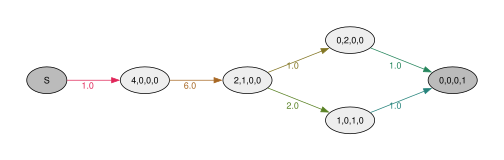

In [ ]:
nr_samples = 4
indexer = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_samples)]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state, indexer=None):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param, indexer=indexer)
graph.plot(dark=False)

## Joint probability-tabel og deficit

In [ ]:
#| label: fig-joint-prob-graf
#| fig-cap: 'Joint probability-graf for koalescent med $n=4$, reward_limit=5, mutation_rate=1e-4.'

reward_limit    = 5
reward_limit_im = 5
pop_size        = 10_000
theta           = 1 / pop_size
mutation_rate   = 1e-4
mut_im          = 1e-8
true_coal_im    = 1 / 10_000
t_split_im      = 0.5

joint_prob_graph = graph.joint_prob_graph(
    indexer,
    reward_limit=reward_limit,
    mutation_rate=mutation_rate,
)
true_theta = [theta, mutation_rate]
joint_prob_graph.update_weights(true_theta)

jp_im = graph.joint_prob_graph(
    indexer,
    reward_limit=reward_limit_im,
    mutation_rate=mut_im,
    discrete=False,
)
jp_im.update_weights([true_coal_im, mut_im])

joint_prob_table = joint_prob_graph.joint_prob_table()
deficit = (1 - joint_prob_table['prob'].sum()).item()

display(joint_prob_table.head(10))

,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
9,0,0,0,0,9.996334e-01
19,0,1,0,0,9.994669e-05
21,1,0,0,0,1.999023e-04
24,0,0,1,0,6.662890e-05
36,0,2,0,0,1.665434e-08
38,2,0,0,0,2.887090e-08
41,1,0,1,0,2.220623e-08
43,0,0,2,0,6.661558e-09
45,1,1,0,0,1.776682e-08


In [7]:
print(f'joint_prob_graph: {joint_prob_graph.vertices_length()} tilstande, deficit={deficit:.2e}')
print(f'jp_im: {jp_im.vertices_length()} tilstande (discrete=False)')

joint_prob_graph: 514 tilstande, deficit=2.22e-16
jp_im: 514 tilstande (discrete=False)


### Deficit som funktion af reward_limit

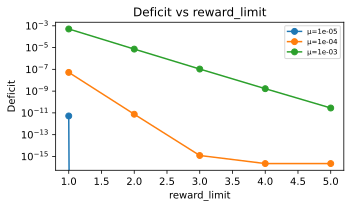

In [ ]:
#| label: fig-deficit
#| fig-cap: 'Deficit som funktion af `reward_limit` for tre mutationsrater $\mu \in \{10^{-5}, 10^{-4}, 10^{-3}\}$. x-aksen viser `reward_limit` og y-aksen viser deficit på log-skala. Hver kurve svarer til en mutationsrate: $\mu=10^{-5}$ (blå), $\mu=10^{-4}$ (orange) og $\mu=10^{-3}$ (grøn).'
#| fig-width: 5
#| fig-height: 3.5

reward_limits = [1, 2, 3, 4, 5]
mutation_rates_test = [1e-5, 1e-4, 1e-3]
fig, ax = plt.subplots(figsize=(5, 3))
for mr in mutation_rates_test:
    deficits = []
    for rl in reward_limits:
        jp_test = graph.joint_prob_graph(indexer, reward_limit=rl, mutation_rate=mr)
        jp_test.update_weights([theta, mr])
        jpt = jp_test.joint_prob_table()
        deficits.append((1 - jpt['prob'].sum()).item())
    ax.semilogy(reward_limits, deficits, marker='o', label=f'μ={mr:.0e}')
ax.set_xlabel('reward_limit'); ax.set_ylabel('Deficit')
ax.set_title('Deficit vs reward_limit'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show();

## Marginal SFS fra joint probability-tabellen

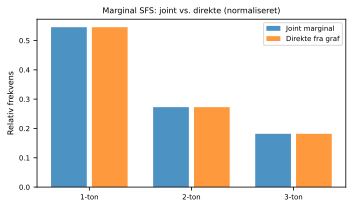

In [ ]:
#| label: fig-marginal-sfs
#| fig-cap: 'Normaliseret marginal SFS beregnet fra joint probability-tabellen (blå) sammenlignet med SFS beregnet direkte fra coalescent-grafen via reward-transformation (orange). x-aksen viser frekvensklasse og y-aksen viser relativ frekvens normaliseret til sum $1$.'
#| fig-width: 5
#| fig-height: 3.5

tons = list(range(1, nr_samples))
marginals_joint = [
    float(np.sum(joint_prob_table[f'descendants_{t}'] * joint_prob_table['prob']))
    for t in tons
]

graph.update_weights([theta])
reward_matrix = graph.states().T
marginals_direct = []
for t in range(len(tons)):
    reward_vec = reward_matrix[t]
    transformed = graph.reward_transform(reward_vec)
    exp_brlen = transformed.moments(1)[0]
    marginals_direct.append(float(exp_brlen * mutation_rate))

total_joint  = sum(marginals_joint)
total_direct = sum(marginals_direct)
marginals_joint_norm  = [x / total_joint  for x in marginals_joint]
marginals_direct_norm = [x / total_direct for x in marginals_direct]

fig, ax = plt.subplots(figsize=(5, 3))
x = np.arange(len(tons))
ax.bar(x - 0.2, marginals_joint_norm,  0.35, label='Joint marginal',   alpha=0.8)
ax.bar(x + 0.2, marginals_direct_norm, 0.35, label='Direkte fra graf', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{t}-ton' for t in tons], fontsize=8)
ax.set_ylabel('Relativ frekvens', fontsize=8)
ax.set_title('Marginal SFS: joint vs. direkte (normaliseret)', fontsize=8)
ax.legend(fontsize=7); ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

In [11]:
print('Joint (norm): ', [round(x, 4) for x in marginals_joint_norm])
print('Direkte (norm):', [round(x, 4) for x in marginals_direct_norm])


Joint (norm):  [0.5455, 0.2727, 0.1818]
Direkte (norm): [0.5455, 0.2727, 0.1818]


## Prior-sammenligning for joint probability-inferens

In [10]:
def sample_joint_observations(jp_graph, theta, n_obs):
    jp_graph.update_weights(theta)
    jpt = jp_graph.joint_prob_table()
    p = (jpt['prob'] / jpt['prob'].sum()).to_numpy()
    idx = np.random.choice(jpt.index.values, size=n_obs, p=p)
    return jpt.loc[idx, jpt.columns[:-1]].to_numpy().tolist()

observations = sample_joint_observations(joint_prob_graph, true_theta, n_obs=BEST_NOBS)
print(f'Simulerede {BEST_NOBS} observationer')
print(f'Første 3: {observations[:3]}')

Simulerede 50000 observationer
Første 3: [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]


In [ ]:
#| label: tbl-prior-joint
#| tbl-cap: 'Prior-sammenligning for joint probability SVGD med sand $\theta=10^{-4}$ og $\mu$ fast. Kolonnerne viser prior-navn, posterior-mean $\hat{\theta}$, posterior-std, absolut bias og om sand $\theta$ dækkes i $95\%$-intervallet.'

prior_configs_jp = {
    'LogGaussPrior': LogGaussPrior(ci=[1/50_000, 1/5_000]),
    'GaussPrior':    GaussPrior(ci=[1/50_000, 1/5_000]),
}

rows_prior_jp = []
for name, prior in prior_configs_jp.items():
    sv = joint_prob_graph.svgd(
        observations,
        fixed=[(1, mutation_rate)],
        prior=prior,
        preconditioner=None,
        n_particles=20,
        n_iterations=300,
        learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0),
    )
    res = sv.get_results()
    m = float(res['theta_mean'][0].item())
    s = float(res['theta_std'][0].item())
    rows_prior_jp.append({
        f'Prior':  name,
        f'θ̂':      round(m, 6),
        f'Std':    round(s, 7),
        f'Bias':   round(abs(m - theta), 6),
        f'Dækker': (m - 1.96*s) <= theta <= (m + 1.96*s),
    })

df_prior_jp = pd.DataFrame(rows_prior_jp)
display(df_prior_jp)

,Prior,θ̂,Std,Bias,Dækker
0,LogGaussPrior,0.000088,0.000036,0.000012,True
1,GaussPrior,0.000111,0.000036,0.000011,True


In [14]:
BEST_PRIOR_JP = df_prior_jp.sort_values('Bias').iloc[0]['Prior']
print(f'Bedste prior til joint: {BEST_PRIOR_JP}')

Bedste prior til joint: GaussPrior


In [ ]:
JOINT_LR_KWARGS = {'learning_rate': ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)}
JOINT_PARTICLES  = 40
JOINT_ITER       = 200

## SVGD-inferens på joint probability-data

In [20]:
#| label: fig-joint-svgd-ci
#| fig-cap: 'Posterior CI for SVGD-inferens på joint probability-data (sand θ=1e-4, μ fastlåst, BEST_PRIOR_JP, JOINT_ITER iter).'#| fig-width: 5
#| fig-height: 3

svgd_jp = joint_prob_graph.svgd(
    observations,
    fixed=[(1, mutation_rate)],
    prior=prior_configs_jp[BEST_PRIOR_JP],
    preconditioner=None,
    n_particles=40,
    n_iterations=200,
    **JOINT_LR_KWARGS,
)
svgd_jp.summary(ci_method='hpd', ci_level=0.95)

Parameter  Fixed          MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No             0.0001186  0.0001002  2.411e-05  5.407e-05    0.0001309   
1          Yes            0.0001     NA         NA         NA           NA          

Particles: 40, Iterations: 200


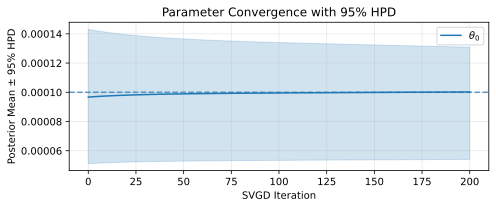

In [ ]:
#| label: fig-joint-svgd-ci-plot
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ over 200 SVGD-iterationer for joint probability-inferens med sand $\theta=10^{-4}$ og $\mu$ fastlåst. Stiplet linje markerer sand $\theta$.'
#| fig-width: 5
#| fig-height: 3.5

svgd_jp.plot_ci(ci_method='hpd', true_theta=[theta])

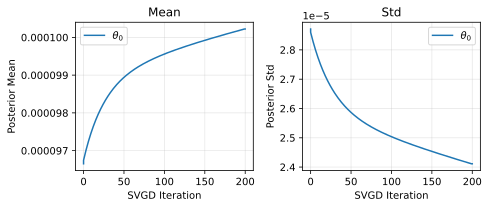

In [ ]:
#| label: fig-joint-svgd-conv
#| fig-cap: 'Posterior mean (venstre) og posterior std (højre) for $\theta_0$ over 200 SVGD-iterationer for joint probability-inferens med sand $\theta=10^{-4}$ og $\mu$ fastlåst.'
#| fig-width: 5
#| fig-height: 3.5

svgd_jp.plot_convergence()

## IM-modellen: SVGD-inferens via epoch_starts

In [ ]:
from phasic import Graph, with_ipv, ExpStepSize, LogGaussPrior, StateIndexer, Property
import msprime
import numpy as np
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

reward_limit = 5
mut_rate   = 1.0e-8
rec_rate   = 1e-8
nr_samples = 4
seq_length = 10_000_000
epoch_starts    = [0, 0.2]
epoch_pop_sizes = [10_000, 10_000]

demography = msprime.Demography()
demography.add_population(name="pop", initial_size=epoch_pop_sizes[0])
for s, t in zip(epoch_starts[1:], epoch_pop_sizes[1:]):
    demography.add_population_parameters_change(time=t, initial_size=s, population="pop")

ts = msprime.sim_ancestry(samples={"pop": nr_samples}, ploidy=1,
                           demography=demography, recombination_rate=rec_rate,
                           sequence_length=seq_length, random_seed=42)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=42)

observations = []
tree_spans = []
for tree in ts.trees():
    obs = [0] * nr_samples
    for site in tree.sites():
        for mut in site.mutations:
            ton = len(list(tree.leaves(mut.node)))
            obs[ton-1] += 1
    if obs[-1] or max(obs) > reward_limit:
        continue
    observations.append(obs)
    start, end = tree.interval
    tree_spans.append(end - start)

tree_spans = np.array(tree_spans)
base = 8
tree_spans = base**(np.round(np.log(tree_spans)/np.log(base)))
print('unique tree spans (rounded):', np.unique(tree_spans).size)

indexer = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_samples)]
)

@with_ipv([nr_samples] + [0]*(nr_samples-1))
def coalescent(state, indexer=None):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        k = indexer.lineage.props_to_index(
            descendants=p1.descendants + p2.descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent, indexer=indexer)

joint_prob_graph_cont = graph.joint_prob_graph(
    indexer, reward_limit=reward_limit, mutation_rate=mut_rate, discrete=False,
)

sv_im = joint_prob_graph_cont.svgd(
    observations,
    preconditioner=None,
    fixed=[(1, mut_rate)],
    prior=LogGaussPrior(ci=[1/50_000, 1/2000]),
    learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0),
    epoch_starts=epoch_starts,
    exposure=tree_spans,
    exposure_param_index=1,
    progress=True,
    n_iterations=50,
    n_particles=20,
)
sv_im.summary(ci_method='hpd', ci_level=0.95)

Parameter  Fixed          MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No             0.0001208  0.0001338  8.334e-05  4.344e-05    0.0002938   
1          Yes            1e-08      NA         NA         NA           NA          
2          No             0.5601     3.295      2.337      0.9815       8.09        
3          Yes            1e-08      NA         NA         NA           NA          

Particles: 20, Iterations: 50


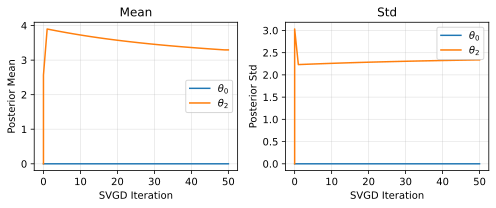

In [ ]:
#| label: fig-im-epoch-conv
#| fig-cap: 'Konvergensplot for IM-modellen med to epoker via epoch_starts ($n=4$, sand $\theta = 4\times10^{-4}$ i begge epoker, $t_s = 0{,}2$). Venstre panel viser posterior mean og højre panel viser posterior std for $\theta_0$ (epoke 0, blå) og $\theta_2$ (epoke 1, orange) over 50 SVGD-iterationer.'
#| fig-width: 5
#| fig-height: 3.5

sv_im.plot_convergence()

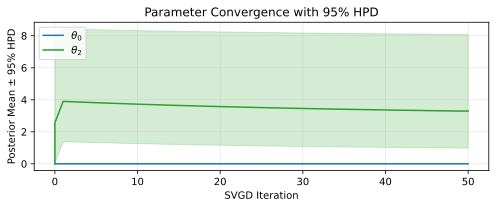

In [ ]:
#| label: fig-im-epoch-ci
#| fig-cap: 'Posterior CI for IM-modellen med to epoker via epoch_starts ($n=4$, sand $\theta = 4\times10^{-4}$ i begge epoker, $t_s = 0{,}2$). Den blå og grønne kurve viser posterior mean for $\theta_0$ (epoke 0) og $\theta_2$ (epoke 1) og de skraverede områder viser de tilsvarende 95% HPD-intervaller over 50 SVGD-iterationer.'
#| fig-width: 5
#| fig-height: 3.5

sv_im.plot_ci(ci_method='hpd')


## ARG-modellen: to-locus joint probability

In [14]:
# To-locus ARG-model med nr_samples=3 (vejlederens kode)
from phasic import Graph, with_ipv, StateIndexer, Property
nr_samples_arg = 3
indexer_arg = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=nr_samples_arg),
        Property('loc2', min_value=0, max_value=nr_samples_arg)
    ]
)

initial_arg = [0] * indexer_arg.state_length
initial_arg[indexer_arg.descendants.props_to_index(loc1=1, loc2=1)] = nr_samples_arg

@with_ipv(initial_arg)
def two_locus_arg(state, indexer=None):
    transitions = []
    if state.sum() <= 1: return transitions
    for i in range(indexer_arg.state_length):
        if state[i] == 0: continue
        props_i = indexer_arg.descendants.index_to_props(i)
        for j in range(i, indexer_arg.state_length):
            if state[j] == 0: continue
            props_j = indexer_arg.descendants.index_to_props(j)
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            child = state.copy()
            child[i] -= 1; child[j] -= 1
            des_loc1 = props_i.loc1 + props_j.loc1
            des_loc2 = props_i.loc2 + props_j.loc2
            if des_loc1 <= nr_samples_arg and des_loc2 <= nr_samples_arg:
                child[indexer_arg.descendants.props_to_index(loc1=des_loc1, loc2=des_loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])
        if state[i] > 0 and props_i.loc1 > 0 and props_i.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer_arg.descendants.props_to_index(loc1=0, loc2=props_i.loc2)] += 1
            child[indexer_arg.descendants.props_to_index(loc1=props_i.loc1, loc2=0)] += 1
            transitions.append([child, [0, state[i]]])
    return transitions

g_arg = Graph(two_locus_arg, indexer=indexer_arg)
print(f'ARG graf: {g_arg.vertices_length()} tilstande, {g_arg.param_length()} parametre')

ARG graf: 32 tilstande, 2 parametre


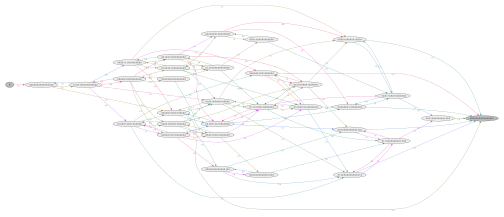

In [ ]:
#| label: fig-arg-graph
#| fig-cap: 'Tilstandsrum for to-locus ARG-modellen med $n=3$ prøver. Hver oval repræsenterer en tilstand, der holder styr på hvilke linjer er fra locus 1, locus 2 eller begge. Pilene viser mulige coalescent- og rekombinationsovergange mellem tilstande. Processen ender i absorptionstilstanden, når alle linjer enten er coalesceret eller skilt ad ved rekombination.'
#| fig-width: 5
#| fig-height: 3.5

g_arg.plot(nodesep=0.5, wrap=False)

In [ ]:
def sample_joint_observations(jp_graph, theta, n_obs):
    jp_graph.update_weights(theta)
    jpt = jp_graph.joint_prob_table()
    p = (jpt['prob'] / jpt['prob'].sum()).to_numpy()
    idx = np.random.choice(jpt.index.values, size=n_obs, p=p)
    return jpt.loc[idx, jpt.columns[:-1]].to_numpy().tolist()

mutation_rate_arg = 1
joint_arg = g_arg.joint_prob_graph(
    indexer_arg,
    reward_only=['loc1', 'loc2'],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate_arg
)

true_theta_arg = [10, 1, mutation_rate_arg]
observations_arg = sample_joint_observations(
    joint_arg, true_theta_arg, n_obs=1000
)
print(f'ARG observationer: {len(observations_arg)}')
print(f'Første 3: {observations_arg[:3]}')

ARG observationer: 1000
Første 3: [[0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0]]


In [ ]:
sv_arg = joint_arg.svgd(
    observations_arg,
    fixed=[(2, mutation_rate_arg)],
    prior=[
        GaussPrior(ci=[5, 25]),
        GaussPrior(ci=[0, 3]),
        None
    ],
    n_particles=40,
    n_iterations=300,
    learning_rate=ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0),
)
sv_arg.summary(ci_method='hpd', ci_level=0.95)

Parameter  Fixed          MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No             7.505      9.873      4.052      6.122        17.37       
1          No             1.115      1.436      0.5412     1.096        2.523       
2          Yes            1          NA         NA         NA           NA          

Particles: 40, Iterations: 300


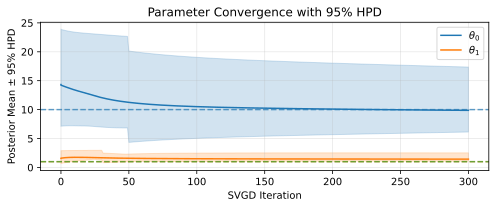

In [ ]:
#| label: fig-arg-svgd-ci
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ (blå) og $\theta_1$ (orange) over 300 SVGD-iterationer for ARG-modellen med sand $\theta=10$ og $\rho=1$. Stiplede linjer markerer sande parametre.'
#| fig-width: 5
#| fig-height: 3.5

sv_arg.plot_ci(ci_method='hpd', true_theta=true_theta_arg)

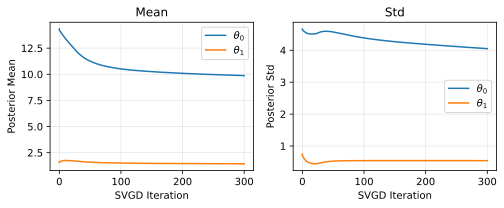

In [ ]:
#| label: fig-arg-conv
#| fig-cap: 'Posterior mean (venstre) og posterior std (højre) for $\theta_0$ (blå) og $\theta_1$ (orange) over 300 SVGD-iterationer for ARG-modellen med sand $\theta=10$ og $\rho=1$.'
#| fig-width: 5
#| fig-height: 3.5

sv_arg.plot_convergence()

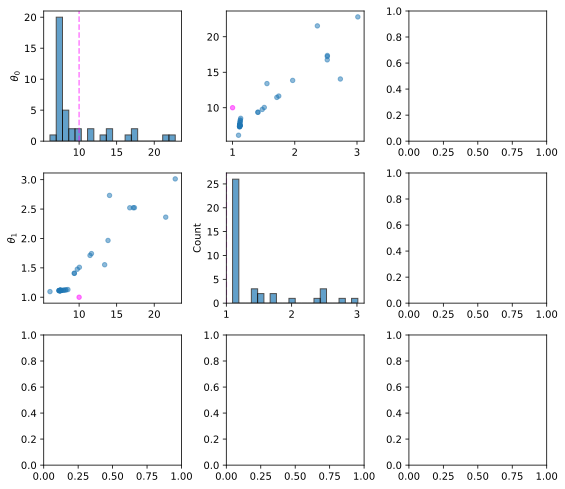

In [ ]:
#| label: fig-arg-pairwise
#| fig-cap: 'Pairwise posterior for ARG-model (θ vs. ρ). Stjerner markerer sande parametre.'
#| fig-width: 5
#| fig-height: 3.5

sv_arg.plot_pairwise(true_theta=true_theta_arg)